In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [2]:
df = pd.read_csv('training_data.csv')
df.set_index('date',inplace=True)
data=df.drop(['NO2_l7','NO2_r7'],axis=1)
data
X=data.drop(['PM25'],axis=1)
Y=data['PM25']


In [3]:
horizon = 7
start = 100

rmse_by_block = []

for i in range(start, len(data) - horizon):

    # expand training window
    train = data.iloc[:i]

    X_train = train[X.columns]
    y_train = train[Y.name]

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    block_preds = []
    block_actuals = []

    # predict next 7 days
    for j in range(horizon):

        test = data.iloc[i + j:i + j + 1]

        pred = model.predict(test[X.columns])[0]

        block_preds.append(pred)
        block_actuals.append(test[Y.name].values[0])

    # evaluate this 7-day window
    rmse_block = np.sqrt(np.mean((np.array(block_preds) - np.array(block_actuals))**2))
    rmse_by_block.append(rmse_block)


In [4]:
print("Avg 7-day RMSE:", np.mean(rmse_by_block))


Avg 7-day RMSE: 2.8485927864210963


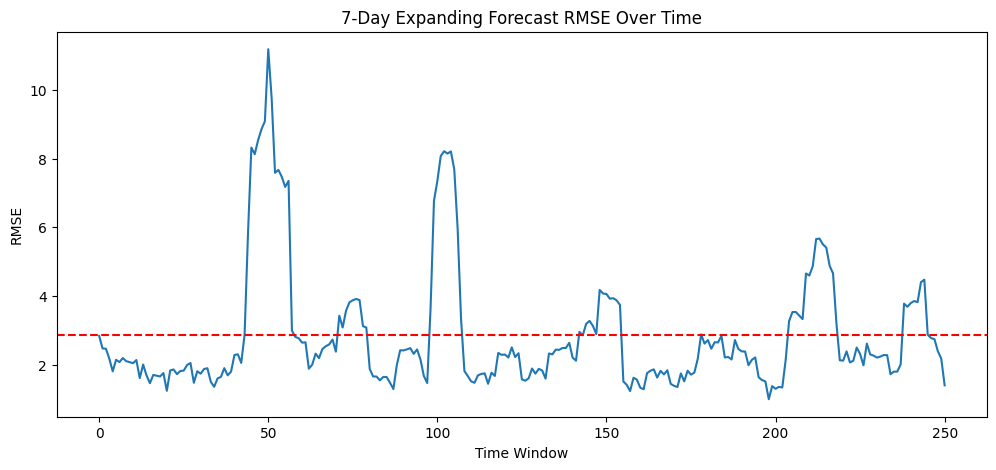

In [5]:
plt.figure(figsize=(12,5))
plt.plot(rmse_by_block)
plt.axhline(np.mean(rmse_by_block), color='red', linestyle='--')
plt.title("7-Day Expanding Forecast RMSE Over Time")
plt.xlabel("Time Window")
plt.ylabel("RMSE")
plt.show()
